In [1]:
from ezphot.utils import DataBrowser
from ezphot.utils import SDTDataQuerier

# Image stacking

## 1. Load data

In [ ]:
# If you connected the database, you can easily sync the data from the database. 
sdtquery = SDTDataQuerier()
sdtquery.help()

Help for SDTDataQuerier


Public methods:
- show_obsdestdata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obsdestfolder(folder_key: str = '*')
- show_obssourcedata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obssourcefolder(folder_key: str = '*')
- show_scidestdata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', pattern: str = '*.fits')
- show_scisourcedata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', file_pattern: str = '*.fits')
- show_scisourcefolder(folder_key: str = '*')
- sync_obsdata(foldername: str, file_pattern: str = '*.fits', ignore_exists: bool = True)
- sync_scidata(targetname: str, file_pattern: str = '*.fits', ignore_exists: bool = True)


In [3]:
# sync_scidata method will run multiple rsync between Science Source directory and destination directory.
print('Source directory:', sdtquery.helper.config['SDTDATA_SCISOURCEDIR'])
print('Target directory:', sdtquery.helper.config['SDTDATA_SCIDESTDIR'])
target_name = 'T00528'
sdtquery.sync_scidata(
    targetname = target_name,
    file_pattern = '*.fits',
    ignore_exists = True
)

Source directory: /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750
Target directory: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1
Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:            rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750/T00528/7DT16/ /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750/T00528/7DT15/ /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT15/rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecte

In [8]:
# Then, you can query your data with DataBrowser class. 
# Since the data is copied to your private directory (['SCIDATA_SCIDESTDIR'](e.g. ~/ezphot/data/scidata by default) in configuration), you can use it as your own data. 
# You can also use it as a context for ezphot. 

dbrowser = DataBrowser('scidata')
# You can query the data with the below keys.
for key, value in dbrowser.keys.items():
    print(key, value)


observatory {'7DT'}
telkey {'7DT_C361K_HIGH_1x1'}
objname {'T13520', 'T21733', 'T06467', 'T05004', 'T20716', 'T02072', 'T10856', 'T11109', 'T03377', 'T03051', 'T24558', 'T12165', 'T00596', 'T05281', 'T07389', 'T16683', 'T14712', 'T14574', 'T10452', 'T00405', 'T02874', 'T24225', 'T06269', 'T01580', 'T25043', 'T02349', 'T02452', 'T21330', 'T13541', 'T23736', 'T00528', 'T00463', 'T10413', 'T13496', 'T15696', 'T00409', 'T11898', 'T00311', 'T22924', 'T24028', 'T03209', 'T01505', 'T01428', 'T13722', 'T25303', 'T25223', 'T13257', 'T11573', 'T23142', 'T23977', 'T13559', 'T13072', 'T21343', 'T11764', 'T04803', 'T01933', 'T00915', 'T12025', 'T04237', 'T11112', 'T08297', 'T05376', 'T11971', 'T22614', 'T14479', 'T13707', 'T12732', 'T02595', 'T03364', 'T07169', 'T00529', 'T23968', 'T01161', 'T13823', 'T13558', 'T14943', 'T11622', 'T00527', 'T09543', 'T23488', 'T11621', 'T13557', 'T14354', 'T09041', 'T19684', 'T17321', 'T09370', 'T06914', 'T08679', 'T00465', 'T05018', 'T03198', 'T13560', 'T13824', '

In [9]:
dbrowser.objname = target_name
dbrowser.telname = '7DT16'
dbrowser.filter = 'r'
dbrowser.search('*100.fits', return_type = 'path')

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


['/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074905_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001416_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074535_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250820_032116_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_000705_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_001035_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001601_r_100.fits',


In [10]:
# If you wish to get the ScienceImage object, 
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images
# If you wish to get the metadata table from the keys, 
metadata_table = dbrowser.search('*100.fits', return_type = 'imginfo')

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


Loading Science Images: 100%|██████████| 66/66 [00:00<00:00, 107.52it/s]


[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'
Loaded 66 FITS files from /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
Total FITS files combined: 66


In [11]:
metadata_table

file,altitude,azimuth,ccd-temp,gain,filter,imgtype,exptime,obsdate,locdate,jd,mjd,binning,object,objctid,obsmode,specmode,note,telescop
str120,str32,str32,str32,str21,str1,str5,str32,str23,str23,str32,str32,str21,str6,str32,str4,str7,str9,str5
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,37.80566,167.202362,-10.0,2750,r,LIGHT,100.0,2025-09-05T00:04:08.000,2025-09-04 20:04:08.000,2460923.50287037,60923.00287037037,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074905_r_100.fits,35.847003,193.97872,-10.2,2750,r,LIGHT,100.0,2025-09-02T07:49:05.000,2025-09-02 03:49:05.000,2460920.8257523146,60920.32575231481,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001416_r_100.fits,37.536132,167.00423,-10.1,2750,r,LIGHT,100.0,2025-09-01T00:14:16.000,2025-08-31 20:14:16.000,2460919.509907407,60919.00990740741,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074535_r_100.fits,36.029225,193.892131,-9.9,2750,r,LIGHT,100.0,2025-09-02T07:45:35.000,2025-09-02 03:45:35.000,2460920.8233217592,60920.32332175926,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250820_032116_r_100.fits,42.588008,174.57094,-10.1,2750,r,LIGHT,100.0,2025-08-20T03:21:16.000,2025-08-19 23:21:16.000,2460907.6397685185,60907.13976851852,1,T00528,58b4f2a07b0246b7b9d68efb4021c28f,Spec,specall,None,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_000705_r_100.fits,37.758685,167.166926,-9.9,2750,r,LIGHT,100.0,2025-09-04T00:07:05.000,2025-09-03 20:07:05.000,2460922.5049189813,60922.00491898148,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_001035_r_100.fits,37.925522,167.294357,-9.9,2750,r,LIGHT,100.0,2025-09-04T00:10:35.000,2025-09-03 20:10:35.000,2460922.507349537,60922.00734953704,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001601_r_100.fits,37.621042,167.065116,-10.2,2750,r,LIGHT,100.0,2025-09-01T00:16:01.000,2025-08-31 20:16:01.000,2460919.5111226854,60919.01112268519,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_075606_r_100.fits,35.478983,194.141241,-10.0,2750,r,LIGHT,100.0,2025-09-02T07:56:06.000,2025-09-02 03:56:06.000,2460920.830625,60920.330625,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16


# Check your image!

(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.fits'}>)

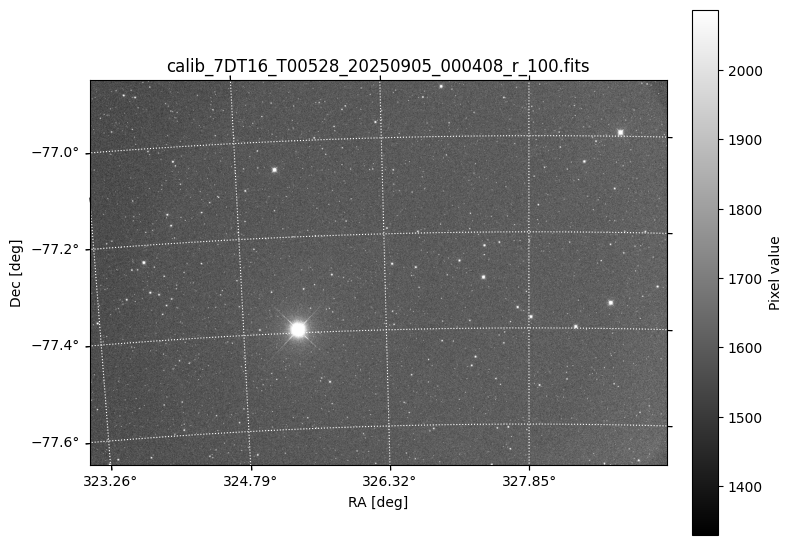

In [12]:
target_imglist[0].show('coord')

In [13]:
# [CAUTION] For memory management, NOTE the below example.
# When you run any functions that load the data, all data are stored in the memory (data_load = True).
target_imglist[0]

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = True,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = r,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)

In [14]:
#To clear the memory, run ScienceImage.clear()
target_imglist[0].clear()
target_imglist[0]

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = r,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)

In [15]:
# You can check the image with ds9 if X11 forward is available (via SSH)
target_imglist[0].run_ds9()

Running "ds9 -scalemode zscale -scale lock yes -frame lock image /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits &" in the terminal...


bash: cannot set terminal process group (2263633): Inappropriate ioctl for device
bash: no job control in this shell


# Image stacking

## 1. Background calculation

[1] 2304486
application-specific initialization failed: no display name and no $DISPLAY environment variable
Unable to initialize window system.


Help for Preprocess

Public methods:
- correct_bd(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_bdf(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, flat_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_bias(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_dark(target_img: ezphot.imageobjects.scienceimage.ScienceImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_flat(target_img: ezphot.imageobjects.scienceimage.ScienceImage, flat_im

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '20250725-zero.fits'}, xlabel='X pixel', ylabel='Y pixel'>)

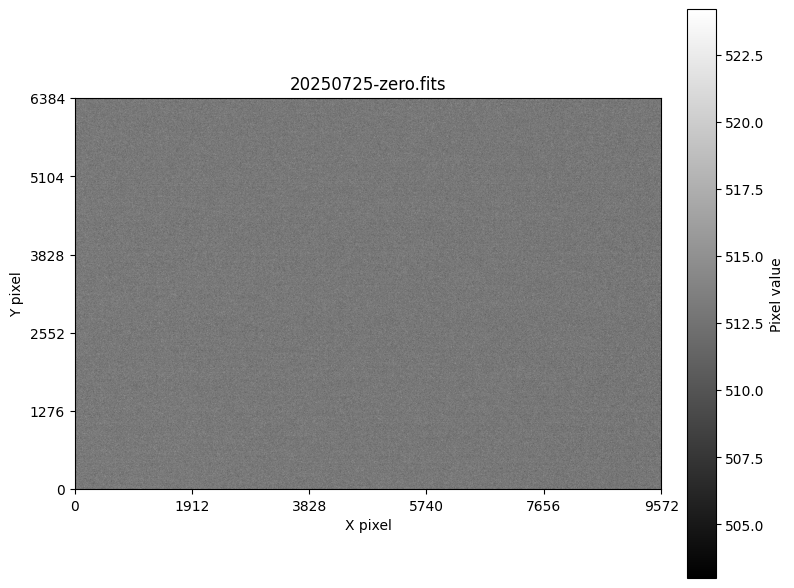

In [18]:
mbias.show('coord')

In [23]:
mbias.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 9576  6388